# FIN 4000 — Chapter 4: Mutual Funds and Other Investment Companies
*NAV, front-end loads, and the compounding cost of fees*

**ANSWER KEY — fully worked, instructor reference**

This notebook is the Python companion to the Chapter 4 Excel template — same data, same formulas, same numbers. Where the Excel workshop has you build a formula in a cell, this notebook has you build it in a line of Python instead.

## Step 1 — Entry Quiz *(3 minutes, individually)*

1. What does NAV stand for, and what's the formula?
2. What's the difference between a load fund and a no-load fund?
3. Why does a higher expense ratio matter more the longer you hold the fund?

---

In [1]:
import numpy as np

## Step 2 — Worked Example *(10 minutes, instructor-led)*

A fund reports the following. Compute its NAV per share, then see what a 1% front-end load does to a $10,000 investment.

In [2]:
assets = 500_000_000
liabilities = 10_000_000
shares_out = 49_000_000

In [3]:
nav = (assets - liabilities) / shares_out
print(f'NAV = ${nav:.2f}')

NAV = $10.00


In [4]:
gross = 10_000
load = 0.01

In [5]:
net_invested = gross * (1 - load)
shares_bought = net_invested / nav
print(f'Net invested=${net_invested:,.0f}  Shares={shares_bought:.1f}')

Net invested=$9,900  Shares=990.0


*NAV per share = (Assets − Liabilities) ÷ Shares outstanding — walk through each term together. Then: with a 1% front-end load, how much of $10,000 is actually invested, and how many shares does that buy?*

## Step 3 — Pair Work *(12 minutes, with a partner)*

**1.** Look up two real funds in the same category: Vanguard 500 Index Fund Admiral Shares (VFIAX, 0.04% expense ratio) and Fidelity Magellan Fund (FMAGX, 0.64% expense ratio). Assuming both had earned the same 7% gross annual return, compute each fund's ending value on a $10,000 investment held for 20 years, net of fees.

In [6]:
start, years, gross_return = 10_000, 20, 0.07
er_vfiax, er_fmagx = 0.0004, 0.0064
fv_vfiax = start * (1 + gross_return - er_vfiax) ** years
fv_fmagx = start * (1 + gross_return - er_fmagx) ** years
print(f'VFIAX=${fv_vfiax:,.2f}  FMAGX=${fv_fmagx:,.2f}  Fee-only gap=${fv_vfiax-fv_fmagx:,.2f}')

VFIAX=$38,408.55  FMAGX=$34,321.52  Fee-only gap=$4,087.02


**2.** Compute the dollar difference between the two ending values — the real-world “fee drag” between these two actual funds.

In [7]:
r_vfiax_10y, r_fmagx_10y = 0.1533, 0.1452
fv_actual_vfiax = start * (1 + r_vfiax_10y) ** 10
fv_actual_fmagx = start * (1 + r_fmagx_10y) ** 10
print(f'Actual 10yr: VFIAX=${fv_actual_vfiax:,.2f}  FMAGX=${fv_actual_fmagx:,.2f}  '
      f'Real-world gap=${fv_actual_vfiax-fv_actual_fmagx:,.2f}')

Actual 10yr: VFIAX=$41,631.58  FMAGX=$38,798.36  Real-world gap=$2,833.22


**3.** Now use each fund's actual trailing 10-year average annual return (VFIAX: 15.33%; FMAGX: 14.52%, both as reported on the funds' own official pages). Compute what $10,000 actually grew to in each fund over the last 10 years, and compare that real-world gap to the fee-only gap from Task 2.

*(Compare the fee-only gap above to the real-world gap — discuss with your partner.)*

## Step 4 — Python Pass *(7 minutes)*

- The 20-year fee-drag model, rebuilt with VFIAX's and FMAGX's real, current expense ratios in place of Fund A and Fund B
- A second block using each fund's actual trailing 10-year return, so the real-world gap sits right next to the fee-only gap
- A formula-driven model — swap in a different real ticker's expense ratio and watch the ending values update

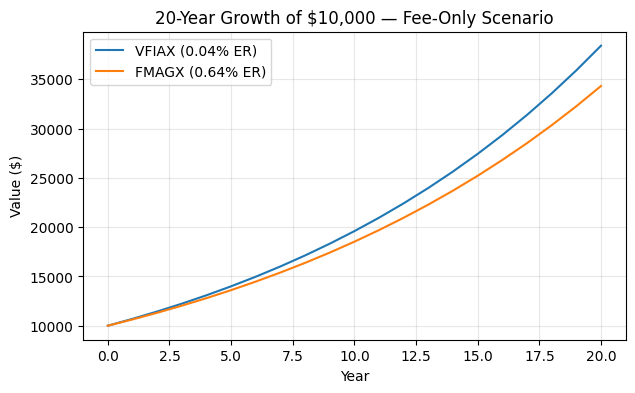

In [8]:
import matplotlib.pyplot as plt
years_arr = np.arange(0, 21)
vfiax_curve = start * (1 + gross_return - er_vfiax) ** years_arr
fmagx_curve = start * (1 + gross_return - er_fmagx) ** years_arr

plt.figure(figsize=(7, 4))
plt.plot(years_arr, vfiax_curve, label='VFIAX (0.04% ER)')
plt.plot(years_arr, fmagx_curve, label='FMAGX (0.64% ER)')
plt.xlabel('Year'); plt.ylabel('Value ($)')
plt.title('20-Year Growth of $10,000 — Fee-Only Scenario')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Step 5 — Discussion *(3-5 minutes, no calculation)*

> Over the last 10 years, VFIAX returned 15.33% annually and FMAGX returned 14.52% — a gap of well under one percentage point a year. Yet compounded at the same assumed 7% gross return over 20 years, that 0.60-point expense-ratio difference alone was worth over $4,000 on a $10,000 investment. Why does such a small annual cost gap create such a large gap in ending wealth?